# Lab: Regression Trees
*This notebook demonstrates the process of building, evaluating, and interpreting a Regression Tree model, structured according to a formal data science [methodology](../../../05_methodology/)*.

---

## 1. Business Understanding
Let's start understanding the problem from a business perspective.

* **Scenario:** We are data scientists working with data from the NYC Taxi and Limousine Commission (TLC). The dataset contains details about  individual taxi trips.
* **Business Objective:** To build a model that can predict the `tip_amount` for a taxi ride based on other trip details (like distance, cost, and passenger count). This could be used to understand factors that influence tipping, analyze driver earnings, or even build features for driver-facing applications.

---

## 2. Analytic Approach
With the business problem defined, we select an analytic approach:
* **Problem Framing:** The business objective is to predict a specific numerical quantity (`tip_amount`), which is a continuous variable. This is a **Regression** problem.
* **Candidate Model:** A **Regression Tree** (`DecisionTreeRegressor`) is an excellent choice. It is highly interpretable, can capture non-linear relationships between features, and does not require extensive feature scaling.
* **Evaluation Metrics:** We will evaluate the model's performance using standard regression metrics:
    * **Mean Squared Error (MSE):** Measures the average squared difference between the actual and predicted values. Lower is better.
    * **R-squared (R²):** Represents the proportion of the variance in the target variable that is predictable from the features. A score closer to 1.0 indicates a better fit.

---

## 3. Data Requirements
To build our model, we need trip data including the fare amount, trip distance, payment type, and other related features. Instead of specifying all the candidate predictors with the help of a domain expert -which is the best practice-, we'll settle with the provided data for this simple project.

---

## 4. Data Collection
The data has already been collected and is available in a CSV file from a public URL, which we will load into a pandas DataFrame.

In [2]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Configurations
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None)

# Helper functions
def rich_print(title, func):
    print(f"=============== {title} ===============\n")
    func()
    print()
    print("="*(70 - len(title)))

In [11]:
# Load the data from the URL
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv'
try:
    df = pd.read_csv(url)
    print("Data loaded successfully from the URL into a DataFrame.")
except Exception as e:
    print(f"Error loading data: {e}")

Data loaded successfully from the URL into a DataFrame.


### Initial Data Ingestion and Verification
Let's perform a quick, high-level check to ensure the collected data is readable and appears correct.

In [12]:
# Display a sample from the data
df.sample(5)

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
13224,2,3,17.66,2,1,132,79,1,70.0,0.5,0.00,1,5.00
37307,2,1,18.46,2,1,132,113,1,70.0,0.5,6.94,1,24.81
34401,2,2,17.42,2,1,132,162,1,70.0,0.5,6.94,1,16.19
5109,2,1,18.61,2,1,132,141,1,70.0,0.5,6.94,1,16.19
36726,2,1,18.67,2,1,132,148,1,70.0,0.5,6.94,1,20.23


In [15]:
# Get the general information 
rich_print("General Information", df.info)

=============== General Information ===============

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB



> 📊 **Data Collection Report:**  
> * The data loads without errors.
> * The number of rows (41.202) and columns (13) seem reasonable. 
> * All columns have the correct data type, and there are no missing values.
> * By glancing at a sample and the data types, we can confirm that **the data matches expectations**.


---

## 5. Data Understanding
Now we'll perform Exploratory Data Analysis to understand the data's characteristics and quality.

Let's first examine the correlation of the features with our target variable, `tip_amount`.

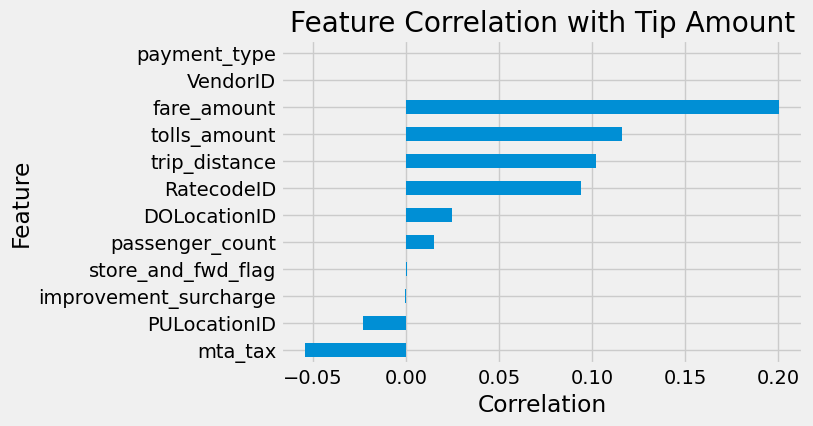

In [19]:
# Calculate and plot correlations with the target variable
plt.figure(figsize=(6, 4))
df.corr()['tip_amount'].drop('tip_amount').sort_values().plot(kind='barh')
plt.title("Feature Correlation with Tip Amount")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

> 📊 **Data Understanding Report:**  
> * The `fare_amount` has a strong positive correlation with the `tip_amount`, which makes intuitive sense—larger fares typically result in larger tips. 
> * `trip_distance` and `total_amount` also show significant correlation. 
> * Other features like `VendorID` and `payment_type` have very weak correlations.